# Performance Evaluation Results


In [1]:
import os

import matplotlib.pyplot as plt

from plot_utils import colors, set_plot_style, set_legend_style
from evaluate_utils import (
    read_performance_results,
    plot_performance_stages,
    compute_performance_speedup,
    print_stage_timing,
    print_frame_timing,
    plot_speedups,
)

RESULTS_DIR = os.path.join('results', 'performance')
EXTINCTIONS = 80, 200, 1000

set_plot_style()

In [2]:
results = {}
for subdir in os.listdir(RESULTS_DIR):
    subdir_path = os.path.join(RESULTS_DIR, subdir)
    if not os.path.isdir(subdir_path):
        continue
    results[subdir] = read_performance_results(subdir_path)

In [3]:
volumes = sorted(
    {
        volume
        for subdir_results in results.values()
        for volume, _ in subdir_results.keys()
    }
)

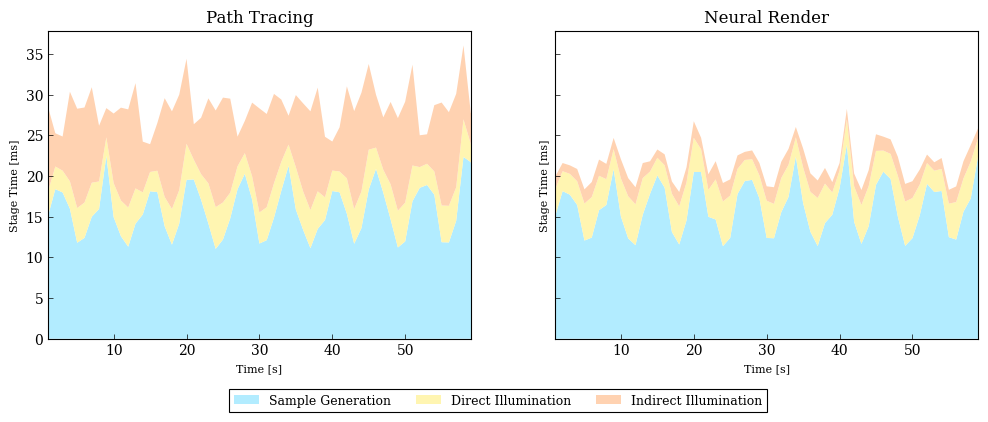

In [4]:
example = 'chameleon', 1000
stage_cols = ['stage_sample_gen', 'stage_direct', 'stage_indirect']
stage_colors = [colors[5], colors[0], colors[2]]

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i, subdir in enumerate(['path_tracing', 'neural_render']):
    plot_performance_stages(ax[i], results[subdir], example, stage_cols, stage_colors)
    ax[i].set_title(subdir.replace('_', ' ').title())
    ax[i].set_xlim(1, 59)
    ax[i].set_xlabel('Time [s]')
    ax[i].set_ylabel('Stage Time [ms]')

handles, labels = ax[0].get_legend_handles_labels()
labels = ['Sample Generation', 'Direct Illumination', 'Indirect Illumination']
legend = fig.legend(
    handles, labels, ncol=4, bbox_to_anchor=(0.5, 0), loc='upper center'
)
set_legend_style(legend)

plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'stage_times.pdf'), bbox_inches='tight'
)
plt.show()

In [5]:
timings = compute_performance_speedup(results)

## Stage Timings

In [6]:
print_stage_timing(timings)

Dataset              Ext.    Ours Ld          Ours Li          Ours L     PT Ld            PT Li            PT L       S Li  S L  
bonsai               80      1.17 ± 0.01      1.31 ± 0.01      2.49       1.17 ± 0.01      1.34 ± 0.01      2.51       1.02  1.01 
                     200     2.87 ± 0.01      1.64 ± 0.01      4.51       2.80 ± 0.01      3.60 ± 0.01      6.41       2.19  1.42 
                     1000    5.19 ± 0.05      2.04 ± 0.01      7.22       4.99 ± 0.04      6.35 ± 0.05      11.34      3.11  1.57 
chameleon            80      1.38 ± 0.03      1.65 ± 0.03      3.03       1.35 ± 0.03      3.12 ± 0.06      4.47       1.89  1.48 
                     200     2.16 ± 0.05      1.73 ± 0.04      3.89       2.08 ± 0.05      6.92 ± 0.18      9.00       4.01  2.31 
                     1000    3.87 ± 0.10      1.74 ± 0.04      5.61       3.68 ± 0.08      9.13 ± 0.30      12.81      5.26  2.28 
csafe_heptane        80      0.64 ± 0.01      1.42 ± 0.02      2.06       0.65 ± 0.

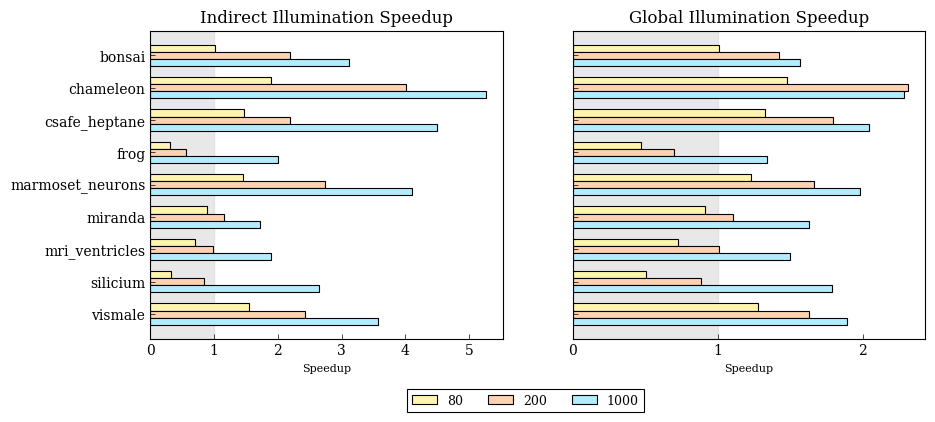

In [7]:
speedup_colors = {
    80: colors[0],
    200: colors[2],
    1000: colors[5],
}

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

plot_speedups(ax[0], timings, 'speedup_Li', speedup_colors, add_labels=True)
plot_speedups(ax[1], timings, 'speedup_L', speedup_colors)

ax[0].set_title('Indirect Illumination Speedup')
ax[1].set_title('Global Illumination Speedup')

volumes = sorted(timings.loc[timings['extinction'].notna(), 'volume'].unique())
ax[0].set_yticks(range(len(volumes)))
ax[0].set_yticklabels(list(reversed(volumes)))

legend = fig.legend(
    loc='upper center',
    ncol=len(speedup_colors),
    bbox_to_anchor=(0.5, 0),
)
set_legend_style(legend)

plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'speedups_L.pdf'), bbox_inches='tight'
)
plt.show()

## Frame Timings

In [8]:
print_frame_timing(timings)

Dataset              Ext.    Ours Frame Time      Ours FPS             PT Frame Time        PT FPS               Speedup
bonsai               80      20.62 ± 0.82         64.20 ± 3.46         21.13 ± 0.81         61.93 ± 3.34         1.02   
                     200     36.93 ± 0.25         27.22 ± 0.18         43.92 ± 0.21         22.83 ± 0.11         1.19   
                     1000    68.89 ± 0.30         14.54 ± 0.06         85.49 ± 0.42         11.73 ± 0.06         1.24   
chameleon            80      53.95 ± 0.35         18.63 ± 0.12         48.39 ± 0.36         20.81 ± 0.16         0.90   
                     200     61.10 ± 0.39         16.45 ± 0.11         80.15 ± 0.71         12.60 ± 0.11         1.31   
                     1000    85.10 ± 0.73         11.85 ± 0.10         111.94 ± 0.88        9.00 ± 0.07          1.32   
csafe_heptane        80      5.77 ± 0.02          173.63 ± 0.48        6.38 ± 0.03          157.14 ± 0.82        1.11   
                     200     6.9

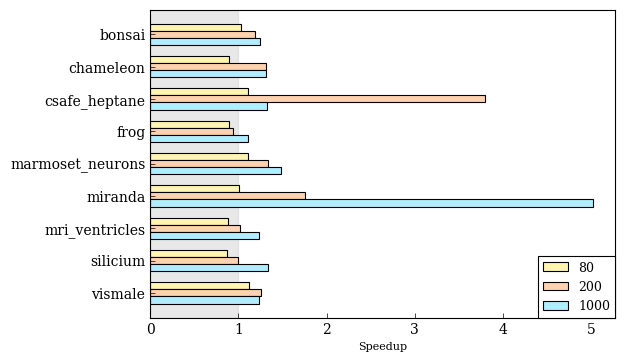

In [10]:
speedup_colors = {
    80: colors[0],
    200: colors[2],
    1000: colors[5],
}

fig, ax = plt.subplots(figsize=(6, 4))

plot_speedups(ax, timings, 'speedup_ft', speedup_colors, add_labels=True)

volumes = sorted(timings.loc[timings['extinction'].notna(), 'volume'].unique())
ax.set_yticks(range(len(volumes)))
ax.set_yticklabels(list(reversed(volumes)))

legend = ax.legend(
    loc='lower right',
    bbox_to_anchor=(1, 0),
    ncol=1,
    borderaxespad=0,
)
set_legend_style(legend)

plt.savefig(
    os.path.join(RESULTS_DIR, '..', 'plots', 'speedups_ft.pdf'), bbox_inches='tight'
)
plt.show()